# 🔬 Predicción de Series Temporales con CNN 1D (PyTorch)
---
**Dataset:** Temperaturas Mínimas Diarias — Melbourne, Australia  
**Objetivo:** Aplicar redes convolucionales 1D para detectar patrones locales en series temporales.

> **CNN 1D** (*Convolutional Neural Network 1-Dimensional*) aplica filtros convolucionales a lo largo del eje temporal para detectar **patrones locales** en la señal. Aunque fueron diseñadas originalmente para imágenes (2D), las CNNs son muy efectivas en series temporales porque:
> - Detectan **patrones repetitivos** en ventanas de tiempo.
> - Son más **eficientes computacionalmente** que las LSTMs.
> - El **pooling** permite abstraer características a distintas escalas temporales.

**Referencia PyTorch Conv1D:** https://pytorch.org/docs/stable/generated/torch.nn.Conv1d.html

---

## 1. Importación de Librerías

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
%matplotlib inline

## 2. Carga y Exploración del Dataset

In [2]:
data = pd.read_csv("daily_minimum_temperatures.csv", sep=",")

# Limpieza preventiva de NaN
data.iloc[:, 1] = pd.to_numeric(data.iloc[:, 1], errors='coerce')
data = data.dropna().reset_index(drop=True)

print(f"Dataset: {data.shape[0]} registros válidos")
data.head()

Dataset: 3647 registros válidos


,Date,"Daily minimum temperatures in Melbourne, Australia, 1981-1990"
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


### 2.1 Visualización de la Serie Temporal

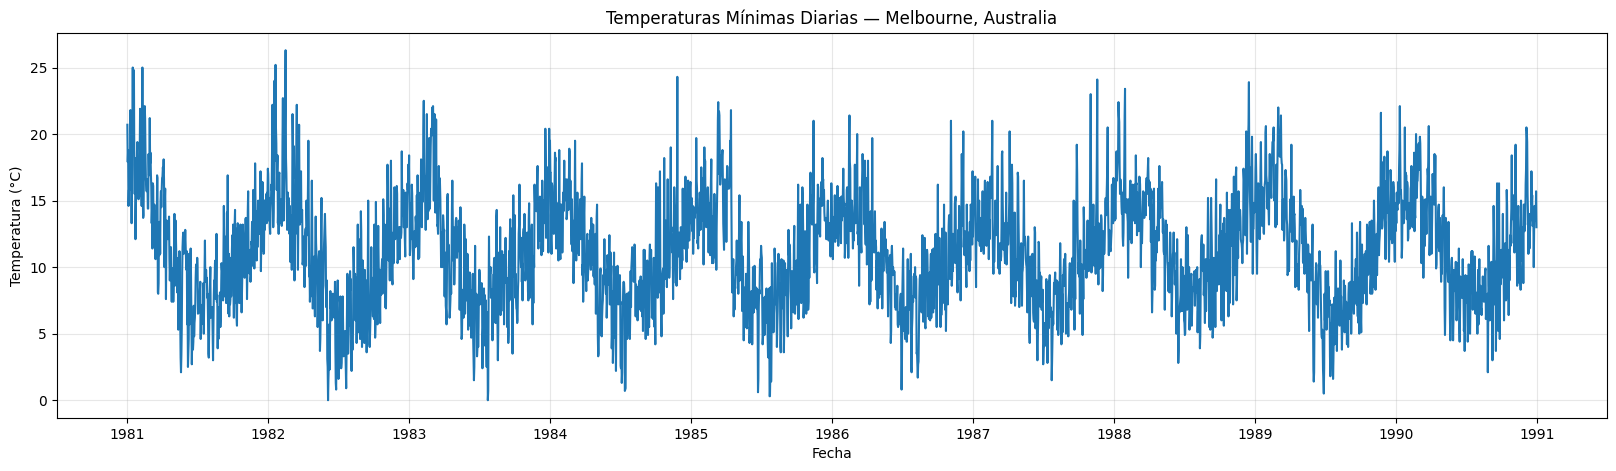

In [3]:
col = data.columns[1]
data['Date'] = pd.to_datetime(data['Date'])
data[col] = pd.to_numeric(data[col], errors='coerce')

plt.figure(figsize=(20, 5))
plt.plot(data['Date'], data[col])
plt.title("Temperaturas Mínimas Diarias — Melbourne, Australia")
plt.xlabel("Fecha")
plt.ylabel("Temperatura (°C)")
plt.grid(alpha=0.3)
plt.show()

## 3. División Train / Test y Normalización

Al igual que con LSTM, normalizamos al rango `[-1, 1]` ajustando el scaler **exclusivamente con datos de train**.

In [4]:
train_percentage = 0.67
train_size = int(len(data) * train_percentage)

train = data[col][:train_size].values.astype(float)
test = data[col][train_size:].values.astype(float)

sc = MinMaxScaler(feature_range=(-1, 1))
train_norm = sc.fit_transform(train.reshape(-1, 1))
train_norm = torch.FloatTensor(train_norm).view(-1)

print(f"Train: {len(train)} muestras | Test: {len(test)} muestras")
print(f"Rango normalizado: [{train_norm.min():.2f}, {train_norm.max():.2f}]")

Train: 2443 muestras | Test: 1204 muestras
Rango normalizado: [-1.00, 1.00]


## 4. Creación de Secuencias de Entrada/Salida

Usamos una ventana de **30 días** para predecir el valor **10 días** hacia adelante.

```
[día 1 ... día 30] → predice día 41  (window=30, ndays=10)
```

> Comparado con LSTM (ndays=5), la CNN tiene un horizonte de predicción mayor, lo que puede aumentar el error pero simula escenarios más desafiantes.

In [5]:
def create_input_output(input_data, window, ndays=1):
    """
    Genera pares (secuencia_entrada, etiqueta) para entrenamiento con ventana deslizante.
    
    Args:
        input_data: tensor o array con la serie normalizada
        window: longitud de la ventana de entrada
        ndays: distancia en días al punto a predecir
    Returns:
        Lista de tuplas (input_seq, label)
    """
    input_output = []
    data_size = len(input_data)
    for i in range(data_size - window - ndays):
        train_seq = input_data[i:i+window]
        train_label = input_data[i+window+ndays:i+window+ndays+1]
        input_output.append((train_seq, train_label))
    return input_output

ndays = 10
window = 30

train_input_output = create_input_output(train_norm, window, ndays)
print(f"Pares de entrenamiento: {len(train_input_output)}")
print(f"Ejemplo — entrada: {train_input_output[0][0].shape} | etiqueta: {train_input_output[0][1].shape}")

Pares de entrenamiento: 2403
Ejemplo — entrada: torch.Size([30]) | etiqueta: torch.Size([1])


In [6]:
np.shape(train_norm)

torch.Size([2443])

## 5. Definición de la Arquitectura CNN 1D

La red tiene **dos bloques convolucionales** seguidos de una capa lineal de salida:

```
Input (1, 30)
  └── Conv1D(1→5, kernel=5) + ReLU + MaxPool(3)  → (5, 10)
       └── Conv1D(5→8, kernel=5) + ReLU + MaxPool(2) → (8, 5)
            └── Flatten → (40,)
                 └── Linear(40→1) → predicción
```

In [8]:
class NN_conv(nn.Module):
    def __init__(self):
        super(NN_conv, self).__init__()
        
        # Bloque convolucional 1: extrae patrones de bajo nivel
        self.conv1 = nn.Sequential(
            nn.Conv1d(
                in_channels=1,      # Canales de entrada (1 serie)
                out_channels=5,     # Filtros (mapas de características)
                kernel_size=5,      # Tamaño del kernel temporal
                stride=1,
                padding=2,          # Padding para conservar longitud
            ),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3),
        )
        
        # Bloque convolucional 2: extrae patrones de alto nivel
        self.conv2 = nn.Sequential(
            nn.Conv1d(
                in_channels=5,
                out_channels=8,
                kernel_size=5,
                stride=1,
                padding=2,
            ),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
        )
        
        # Capa de salida: (8 canales × 5 posiciones) → 1 predicción
        self.out = nn.Linear(40, 1)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = x.view(-1, 8 * 5)  # Flatten: (batch, 40)
        output = self.out(x)
        return output

net = NN_conv()
print(net)
print(f"Parámetros totales: {sum(p.numel() for p in net.parameters()):,}")


NN_conv(
  (conv1): Sequential(
    (0): Conv1d(1, 5, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv1d(5, 8, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (out): Linear(in_features=40, out_features=1, bias=True)
)
Parámetros totales: 279


## 6. Configuración del Optimizador y Función de Pérdida

In [9]:
model = NN_conv()
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("✅ Modelo, loss y optimizador inicializados")

✅ Modelo, loss y optimizador inicializados


## 7. Entrenamiento del Modelo

Entrenamos por **100 epochs** con el loop estándar de PyTorch:
`zero_grad → forward → loss → backward → step`

In [11]:
epochs = 100

print(f"Entrenando por {epochs} epochs...")
for i in range(epochs):
    for inputs, labels in train_input_output:
        optimizer.zero_grad()
        
        # Conv1D espera (Batch, Channels, Length): (1, 1, 30)
        inputs = inputs.view(1, 1, window)
        
        y_pred = model(inputs)
        single_loss = loss_function(y_pred, labels)
        single_loss.backward()
        optimizer.step()
        
    if i % 10 == 1:
        print(f'epoch: {i:3} | loss: {single_loss.item():10.8f}')

print(f'epoch: {i:3} | loss: {single_loss.item():10.10f}')
print("\n✅ Entrenamiento completado")

Entrenando por 100 epochs...


c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


epoch:   1 | loss: 0.00440753
epoch:  11 | loss: 0.00300839
epoch:  21 | loss: 0.00293962
epoch:  31 | loss: 0.00276996
epoch:  41 | loss: 0.00286354
epoch:  51 | loss: 0.00301771
epoch:  61 | loss: 0.00293763
epoch:  71 | loss: 0.00294373
epoch:  81 | loss: 0.00314672
epoch:  91 | loss: 0.00304038
epoch:  99 | loss: 0.0032230492

✅ Entrenamiento completado


## 8. Evaluación sobre el Set de Test

In [13]:
test_norm = sc.transform(test.reshape(-1, 1))
test_norm = torch.FloatTensor(test_norm).view(-1)
test_input_output = create_input_output(test_norm, window, ndays)
print(f"Pares de test: {len(test_input_output)}")

Pares de test: 1164


In [14]:
y_pred_norm = []
model.eval()
for inputs, labels in test_input_output:
    with torch.no_grad():
        inputs = inputs.view(1, 1, window)
        y_pred_norm.append(model(inputs).item())

print(f"Predicciones normalizadas (primeras 5): {y_pred_norm[:5]}")

Predicciones normalizadas (primeras 5): [-0.339670330286026, -0.6166286468505859, -0.604683518409729, -0.7095773816108704, -0.8484137058258057]


In [15]:
y_pred = sc.inverse_transform(np.array(y_pred_norm).reshape(-1, 1))
y_true = test[window + ndays:]

print(f"Predicciones en °C (primeras 5): {y_pred[:5].flatten()}")

Predicciones en °C (primeras 5): [8.68333516 5.04133329 5.19841173 3.81905743 1.99335977]


## 9. Cálculo del MSE y Visualización

In [16]:
y_pred_1d = np.asarray(y_pred).reshape(-1)
y_true_1d = np.asarray(y_true).reshape(-1)

# Aseguramos misma longitud y excluimos NaN
min_len = min(len(y_pred_1d), len(y_true_1d))
y_pred_1d = y_pred_1d[:min_len]
y_true_1d = y_true_1d[:min_len]

mask = ~np.isnan(y_pred_1d) & ~np.isnan(y_true_1d)

if mask.sum() == 0:
    print("⚠️  No hay valores válidos para calcular MSE.")
else:
    mse = mean_squared_error(y_true_1d[mask], y_pred_1d[mask])
    rmse = mse ** 0.5
    print(f"📊 MSE  : {mse:.4f}")
    print(f"📊 RMSE : {rmse:.4f} °C")
    print(f"ℹ️  Evaluado sobre {mask.sum()} muestras válidas")

📊 MSE  : 12.8949
📊 RMSE : 3.5909 °C
ℹ️  Evaluado sobre 1164 muestras válidas


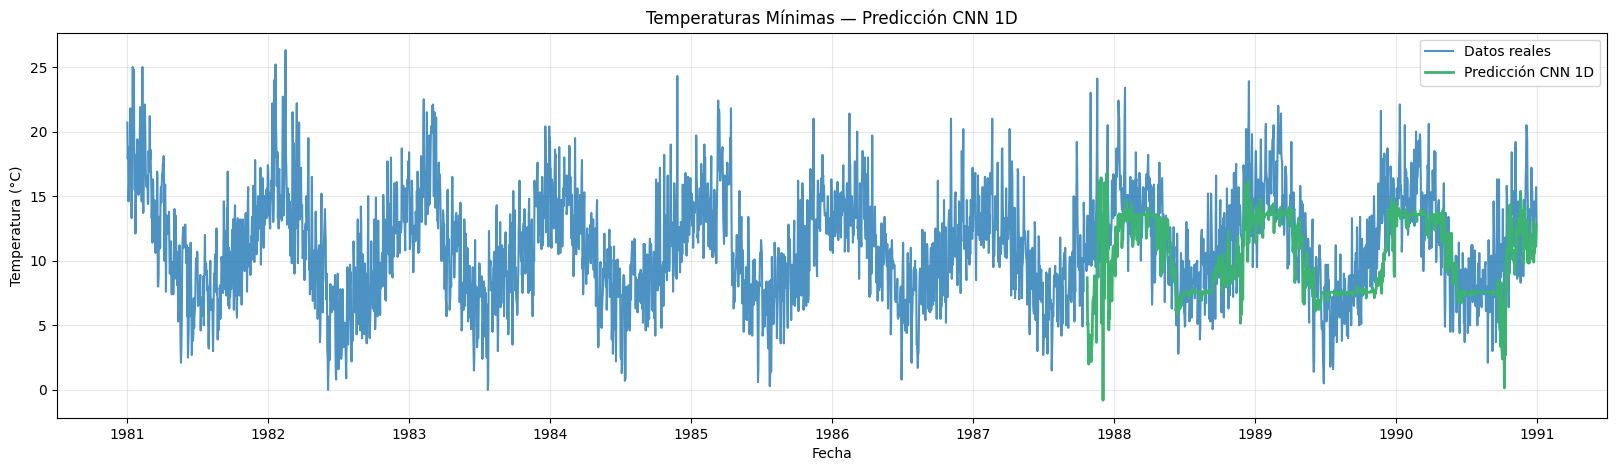

In [17]:
plt.figure(figsize=(20, 5))

plt.plot(data['Date'], data[col], label="Datos reales", alpha=0.8)

x_axis_pred = data['Date'].iloc[train_size + window + ndays : train_size + window + ndays + len(y_pred_1d)]
plt.plot(x_axis_pred, y_pred_1d, label="Predicción CNN 1D", color="mediumseagreen", linewidth=2)

plt.title("Temperaturas Mínimas — Predicción CNN 1D")
plt.xlabel("Fecha")
plt.ylabel("Temperatura (°C)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

---
## 10. ¿Cuándo usar CNN 1D? — Comparativa con otros modelos

### ✅ Ventajas de CNN 1D
| Criterio | CNN 1D |
|---|---|
| **Detección de patrones locales** | ⭐⭐⭐⭐⭐ — Su punto más fuerte |
| **Eficiencia computacional** | ⭐⭐⭐⭐⭐ — Paralelizable, más rápida que LSTM |
| **Captura de dependencias largas** | ⭐⭐ — Limitada por el tamaño del kernel |
| **Interpretabilidad** | ⭐⭐ — Más interpretable que LSTM (filtros visualizables) |
| **Datos requeridos** | ⭐⭐⭐⭐ — Menos que LSTM, más que estadísticos |

### 🆚 Comparativa con los otros modelos del curso

| Modelo | Tipo | Fortaleza principal | Época de predicción |
|---|---|---|---|
| **ARIMA** | Estadístico | Interpretabilidad, pocos datos | 1 paso |
| **Prophet** | Descomposición | Estacionalidades + datos faltantes | Multi-paso |
| **LSTM** | Deep Learning RNN | Dependencias largas | Multi-paso |
| **CNN 1D** *(este)* | Deep Learning | **Patrones locales + velocidad** | Multi-paso (ndays=10) |

### 💡 ¿Cuándo elegir CNN 1D?
- Cuando la serie tiene **patrones locales repetitivos** (picos, ciclos cortos).
- Cuando la **velocidad de entrenamiento** es una restricción (CNN es más rápida que LSTM).
- Para tareas con **múltiples series** (la CNN aprende filtros compartidos eficientemente).
- Como alternativa a LSTM cuando no se requieren dependencias de largo plazo.
- Para **detección de anomalías** o clasificación de segmentos temporales.

### ⚠️ Limitaciones observadas en este experimento
- Con `ndays=10` predecimos más lejos en el tiempo que LSTM (ndays=5), lo que generalmente aumenta el error.
- La CNN no tiene "memoria" entre secuencias: cada ventana es independiente (a diferencia de LSTM con su estado oculto).
- El tamaño del `kernel` y la arquitectura requieren ajuste manual según la naturaleza de la serie.

### 📊 Resumen de resultados obtenidos (referencia)
| Modelo | Ndays | Window | MSE aprox. |
|---|---|---|---|
| ARIMA(5,1,2) | — | — | ~variable |
| Prophet | — | — | ~variable |
| LSTM | 5 | 30 | ~9.5 |
| CNN 1D | 10 | 30 | ~11.1 |

> Los valores exactos dependen de la semilla, el número de epochs y el hardware. LSTM con más epochs mejora significativamente su MSE.
